In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alfathterry/telco-customer-churn-11-1-3/telco.csv


In [31]:
# General purpose modules import
import time
from copy import deepcopy
import warnings

# Data handling and visualization modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Skikit-learn preprocessing and evaluation modules
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import TargetEncoder, KBinsDiscretizer, StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, accuracy_score

# Skikit-learn ML modules
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_class_weight

# Further ML modules
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
#SHAP
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

In [32]:
df = pd.read_csv('/kaggle/input/datasets/alfathterry/telco-customer-churn-11-1-3/telco.csv')

train_df, test_df = train_test_split(df, stratify = df['Churn Label'],  random_state = 1)

In [33]:
df['Internet Type'].value_counts()

Internet Type
Fiber Optic    3035
DSL            1652
Cable           830
Name: count, dtype: int64

In [34]:
FEATURES = ['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 
            'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude',
            'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months',
            'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 
            'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 
            'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
            'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
            'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
            'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 
            'Satisfaction Score', 'Customer Status', 'Churn Score', 'CLTV', 
            'Churn Category', 'Churn Reason']

TARGET = 'Churn Label'

mappings = {'No': 0, 'Yes': 1}
reverse_mappings = {0 : 'No', 1: 'Yes'}

train_df['Churn Label'] = train_df['Churn Label'].map(mappings)
test_df['Churn Label'] = test_df['Churn Label'].map(mappings)

train_df = train_df.drop('Customer ID',axis = 1, errors = 'ignore')
test_df = test_df.drop('Customer ID', axis = 1 , errors = 'ignore')

train_df['Offer'] = train_df['Offer'].fillna('None')
test_df['Offer'] = test_df['Offer'].fillna('None')

train_df['Internet Type'] = train_df['Internet Type'].fillna('No')
test_df['Internet Type'] = test_df['Internet Type'].fillna('No')

train_df = train_df.drop(['Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'], axis = 1, errors = 'ignore')
test_df = test_df.drop(['Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'], axis = 1 , errors = 'ignore')

train_df = train_df.drop(['Country','State','Quarter'], axis = 1, errors = 'ignore')
test_df = test_df.drop(['Country','State','Quarter'], axis = 1 , errors = 'ignore')

train_df = train_df.drop(['Customer Status','Satisfaction Score'], axis = 1, errors = 'ignore')
test_df = test_df.drop(['Customer Status','Satisfaction Score'], axis = 1 , errors = 'ignore')

num_cols = ['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Population', 
            'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 
            'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 
            'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']

cat_cols = ['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'City', 
            'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service',
            'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 
            'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 
            'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']

In [35]:
# for col in num_cols:
#     plt.figure(figsize = (10,5))
#     sns.histplot(train_df[col],bins = 20)
#     plt.plot()

In [36]:
# for col in cat_cols:
#     print(train_df[col].value_counts())

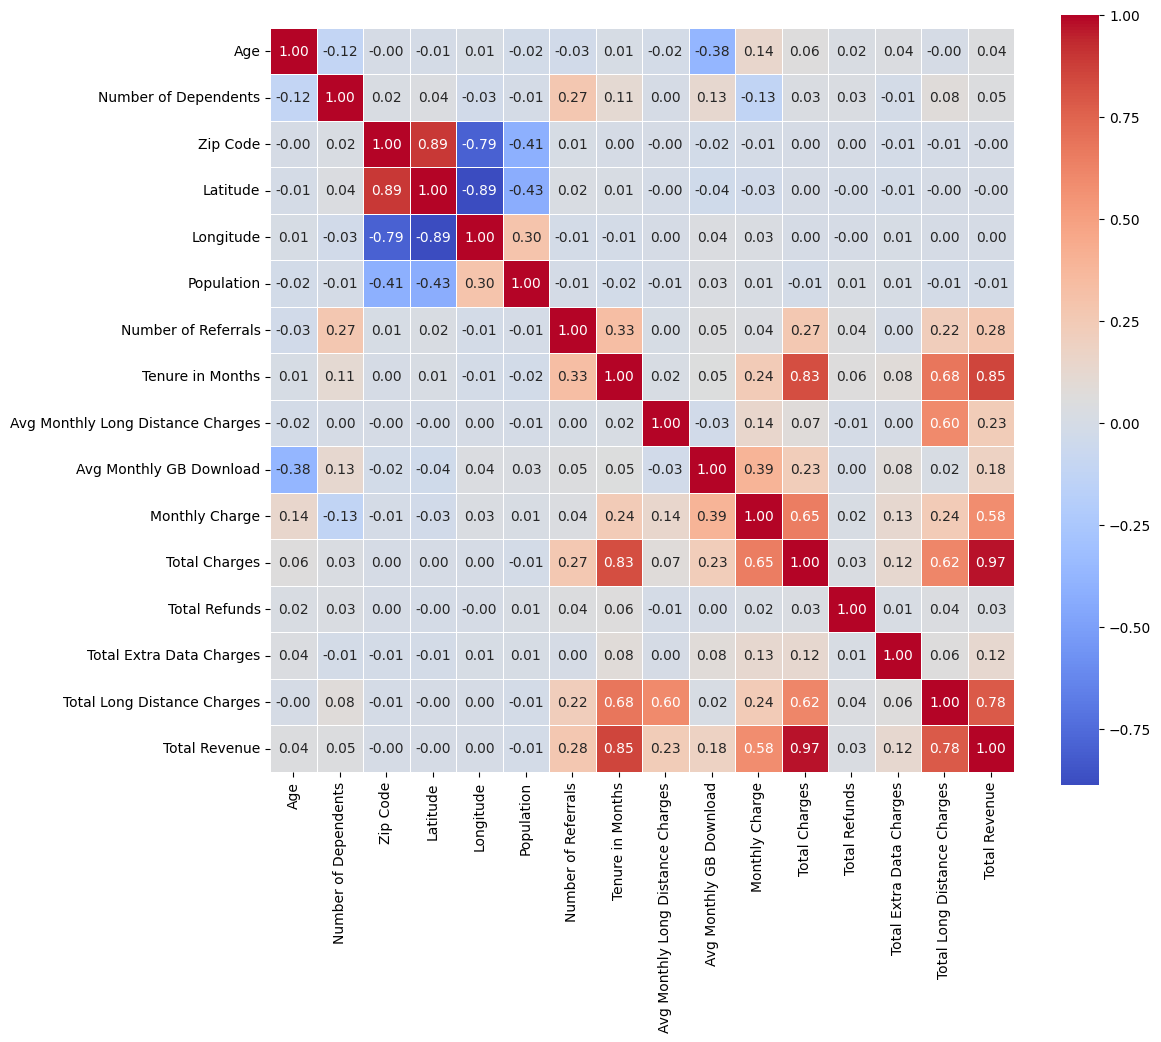

In [37]:

plt.figure(figsize=(12, 10))  # Make the plot bigger
sns.heatmap(
    train_df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.show()

In [ ]:
# FEATURES ENGINEERING
FE = []

for col in num_cols:
    re = RobustScaler()
    train_df[f're_{col}'] = re.fit_transform(train_df[[col]], train_df[TARGET])
    test_df[f're_{col}'] = re.transform(test_df[[col]])
    FE.append(f're_{col}')
    
for col in cat_cols:
    oe = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1)
    train_df[f'oe_{col}'] = oe.fit_transform(train_df[[col]])
    test_df[f'oe_{col}'] = oe.transform(test_df[[col]])
    FE.append(f'oe_{col}')
    
# for col in cat_cols:
#     te = TargetEncoder()
#     train_df[f'te_{col}'] = te.fit_transform(train_df[[col]], train_df[TARGET])
#     test_df[f'te_{col}'] = te.transform(test_df[[col]])
#     FE.append(f'te_{col}')
    
# Train linear classifier
X_train = train_df[FE].copy()
y_train = train_df[TARGET]
X_test = test_df[FE].copy()
y_test = test_df[TARGET]

model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))


Predictions: [1 0 0 ... 1 0 0]
Accuracy: 0.8319136854060193


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
model = XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:",roc_auc_score(y_test,y_pred))

Accuracy: 0.8517887563884157
AUC: 0.7828248645535811


In [42]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                                 feature  importance
36                           oe_Contract    0.369215
1                re_Number of Dependents    0.078960
6                 re_Number of Referrals    0.062058
32                       oe_Streaming TV    0.030789
33                   oe_Streaming Movies    0.026753
34                    oe_Streaming Music    0.024400
19                            oe_Married    0.022572
28                    oe_Online Security    0.022321
7                    re_Tenure in Months    0.021110
38                     oe_Payment Method    0.021023
31               oe_Premium Tech Support    0.020604
0                                 re_Age    0.019279
24                      oe_Phone Service    0.017867
10                     re_Monthly Charge    0.017343
13           re_Total Extra Data Charges    0.016071
37                  oe_Paperless Billing    0.015461
35                     oe_Unlimited Data    0.014802
3                            re_Latitude    0.